## Linear Regression Task on Life Expectancy

### PART 1: Environment Setup

In [68]:
# Libraries to be used
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [69]:
# initialize the path to the zipfile 
path = './data/life-expectancy-and-socio-economic-world-bank.zip'
path_dir = './data'

#extract the zipfile to same directory
with zipfile.ZipFile(path, 'r') as file:
    file.extractall(path_dir)
print('Dataset extracted successfully!')

Dataset extracted successfully!


In [70]:
# Loading the dataset into a DataFrame
data = pd.read_csv('./data/life expectancy.csv')

# Displaying the first 5 rows of the dataset
data.head()

,Country Name,Country Code,Region,IncomeGroup,Year,Life Expectancy World Bank,Prevelance of Undernourishment,CO2,Health Expenditure %,Education Expenditure %,Unemployment,Corruption,Sanitation,Injuries,Communicable,NonCommunicable
0,Afghanistan,AFG,South Asia,Low income,2001,56.308,47.8,730.0,NaN,NaN,10.809000,NaN,NaN,2179727.10,9689193.70,5795426.38
1,Angola,AGO,Sub-Saharan Africa,Lower middle income,2001,47.059,67.5,15960.0,4.483516,NaN,4.004000,NaN,NaN,1392080.71,11190210.53,2663516.34
2,Albania,ALB,Europe & Central Asia,Upper middle income,2001,74.288,4.9,3230.0,7.139524,3.4587,18.575001,NaN,40.520895,117081.67,140894.78,532324.75
3,Andorra,AND,Europe & Central Asia,High income,2001,NaN,NaN,520.0,5.865939,NaN,NaN,NaN,21.788660,1697.99,695.56,13636.64
4,United Arab Emirates,ARE,Middle East & North Africa,High income,2001,74.544,2.8,97200.0,2.484370,NaN,2.493000,NaN,NaN,144678.14,65271.91,481740.70


In [71]:
# Displaying the shape of the dataset
print('Dataset has {} rows and {} columns.'.format(data.shape[0], data.shape[1]))

Dataset has 3306 rows and 16 columns.


In [72]:
# Renaming the column names for easier access
data.rename(
    columns={
        'Country Name': 'Country',
        'Country Code': 'Code',
        'IncomeGroup': 'Income_Group',
        'Life Expectancy World Bank': 'Life_Expectancy',
        'Prevelance of Undernourishment': 'Undernourishment',
        'Health Expenditure %': 'Health_Exp',
        'Education Expenditure %': 'Education_Exp'
    },
    inplace=True    
)
data.columns.to_list()

['Country',
 'Code',
 'Region',
 'Income_Group',
 'Year',
 'Life_Expectancy',
 'Undernourishment',
 'CO2',
 'Health_Exp',
 'Education_Exp',
 'Unemployment',
 'Corruption',
 'Sanitation',
 'Injuries',
 'Communicable',
 'NonCommunicable']

## PART 2: Exploratory Data Analysis

### Data Overview and Missing Values

In [73]:
# Getting to Understand more the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           3306 non-null   str    
 1   Code              3306 non-null   str    
 2   Region            3306 non-null   str    
 3   Income_Group      3306 non-null   str    
 4   Year              3306 non-null   int64  
 5   Life_Expectancy   3118 non-null   float64
 6   Undernourishment  2622 non-null   float64
 7   CO2               3154 non-null   float64
 8   Health_Exp        3126 non-null   float64
 9   Education_Exp     2216 non-null   float64
 10  Unemployment      3002 non-null   float64
 11  Corruption        975 non-null    float64
 12  Sanitation        2059 non-null   float64
 13  Injuries          3306 non-null   float64
 14  Communicable      3306 non-null   float64
 15  NonCommunicable   3306 non-null   float64
dtypes: float64(11), int64(1), str(4)
memory usage: 413.4 

In [74]:
#Statistical summary of the dataset
data.describe()

,Year,Life_Expectancy,Undernourishment,CO2,Health_Exp,Education_Exp,Unemployment,Corruption,Sanitation,Injuries,Communicable,NonCommunicable
count,3306.000000,3118.000000,2622.000000,3.154000e+03,3126.000000,2216.000000,3002.000000,975.000000,2059.000000,3.306000e+03,3.306000e+03,3.306000e+03
mean,2010.000000,69.748362,10.663654,1.574924e+05,6.364059,4.589014,7.890760,2.860513,52.738785,1.318219e+06,4.686289e+06,7.392488e+06
std,5.478054,9.408154,11.285897,7.726415e+05,2.842844,2.119165,6.270832,0.621343,30.126762,5.214068e+06,1.843727e+07,2.932688e+07
min,2001.000000,40.369000,2.500000,1.000000e+01,1.263576,0.850320,0.100000,1.000000,2.377647,4.304900e+02,3.301600e+02,2.481820e+03
25%,2005.000000,63.642000,2.500000,2.002500e+03,4.205443,3.136118,3.733000,2.500000,24.746007,6.245688e+04,5.776475e+04,3.184758e+05
50%,2010.000000,72.168500,6.200000,1.020500e+04,5.892352,4.371465,5.920000,3.000000,49.317481,2.456910e+05,3.147693e+05,1.350146e+06
75%,2015.000000,76.809000,14.775000,5.877250e+04,8.119166,5.519825,10.097500,3.250000,80.278847,8.465591e+05,2.831636e+06,3.918468e+06
max,2019.000000,84.356341,70.900000,1.070722e+07,24.230680,23.270000,37.250000,4.500000,100.000004,5.563676e+07,2.685646e+08,3.246378e+08


In [75]:
# Checking for missing values in the dataset and their percentage per column
missing_df = pd.DataFrame({
    'Missing Count': data.isnull().sum(),
    'Missing %': (data.isnull().sum() / len(data) * 100).round(2)
})

# Show only columns that actually have missing values
# and Sort by percentage of missing values in descending order

print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))


                  Missing Count  Missing %
Corruption                 2331      70.51
Sanitation                 1247      37.72
Education_Exp              1090      32.97
Undernourishment            684      20.69
Unemployment                304       9.20
Life_Expectancy             188       5.69
Health_Exp                  180       5.44
CO2                         152       4.60


### Data Visualization and Interpretation

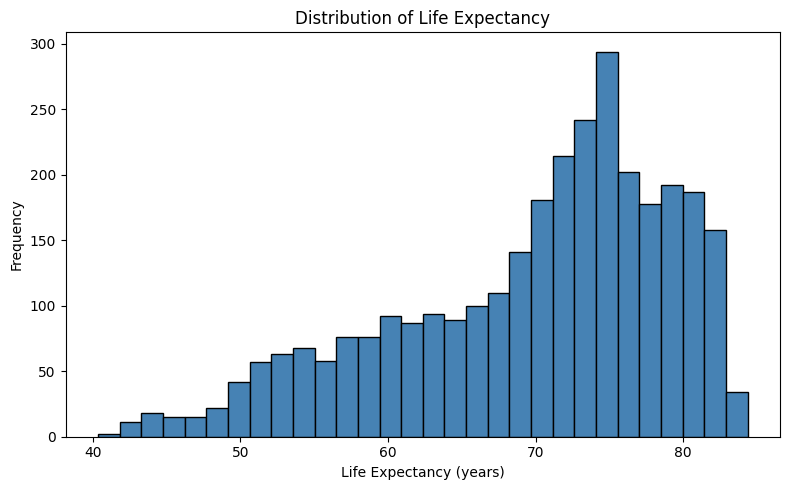

In [76]:
# Histogram of the 'Life expectancy' column which is the target variable

plt.figure(figsize=(8, 5))
plt.hist(data['Life_Expectancy'].dropna(), bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

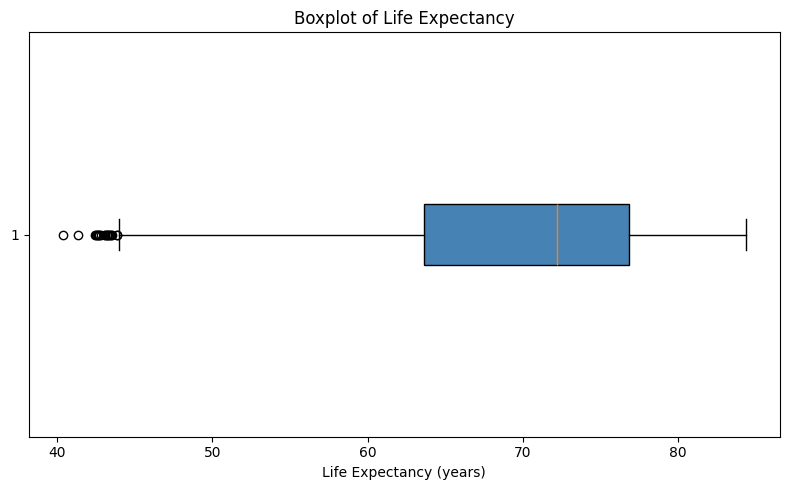

In [77]:
# Boxplot of Life Expectancy to detect outliers
plt.figure(figsize=(8, 5))
plt.boxplot(data['Life_Expectancy'].dropna(), vert=False, patch_artist=True, 
            boxprops=dict(facecolor='steelblue', color='black'))
plt.title('Boxplot of Life Expectancy')
plt.xlabel('Life Expectancy (years)')
plt.tight_layout()
plt.show()

Dropping (non-numeric & above 40% missing values) columns before hitmap correlation

In [ ]:
# Dropping Columns with more than 30% missing values
# and non-numeric columns
cleaned_data = data.drop(columns=[
    'Year', # time index
    'Country', #Just a label 
    'Code', # same as country, no numerical value
    'Region', # no numerical value
    'Corruption', # missing 70% of the values
    ])
cleaned_data.head()

,Income_Group,Life_Expectancy,Undernourishment,CO2,Health_Exp,Education_Exp,Unemployment,Sanitation,Injuries,Communicable,NonCommunicable
0,Low income,56.308,47.8,730.0,NaN,NaN,10.809000,NaN,2179727.10,9689193.70,5795426.38
1,Lower middle income,47.059,67.5,15960.0,4.483516,NaN,4.004000,NaN,1392080.71,11190210.53,2663516.34
2,Upper middle income,74.288,4.9,3230.0,7.139524,3.4587,18.575001,40.520895,117081.67,140894.78,532324.75
3,High income,NaN,NaN,520.0,5.865939,NaN,NaN,21.788660,1697.99,695.56,13636.64
4,High income,74.544,2.8,97200.0,2.484370,NaN,2.493000,NaN,144678.14,65271.91,481740.70


In [79]:
# Filling missing values in numeric columns with the mean of each column
cleaned_data.fillna(cleaned_data.mean(numeric_only=True), inplace=True)

# Final check of the cleaned dataset
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3306 entries, 0 to 3305
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Income_Group      3306 non-null   str    
 1   Life_Expectancy   3306 non-null   float64
 2   Undernourishment  3306 non-null   float64
 3   CO2               3306 non-null   float64
 4   Health_Exp        3306 non-null   float64
 5   Education_Exp     3306 non-null   float64
 6   Unemployment      3306 non-null   float64
 7   Sanitation        3306 non-null   float64
 8   Injuries          3306 non-null   float64
 9   Communicable      3306 non-null   float64
 10  NonCommunicable   3306 non-null   float64
dtypes: float64(10), str(1)
memory usage: 284.2 KB


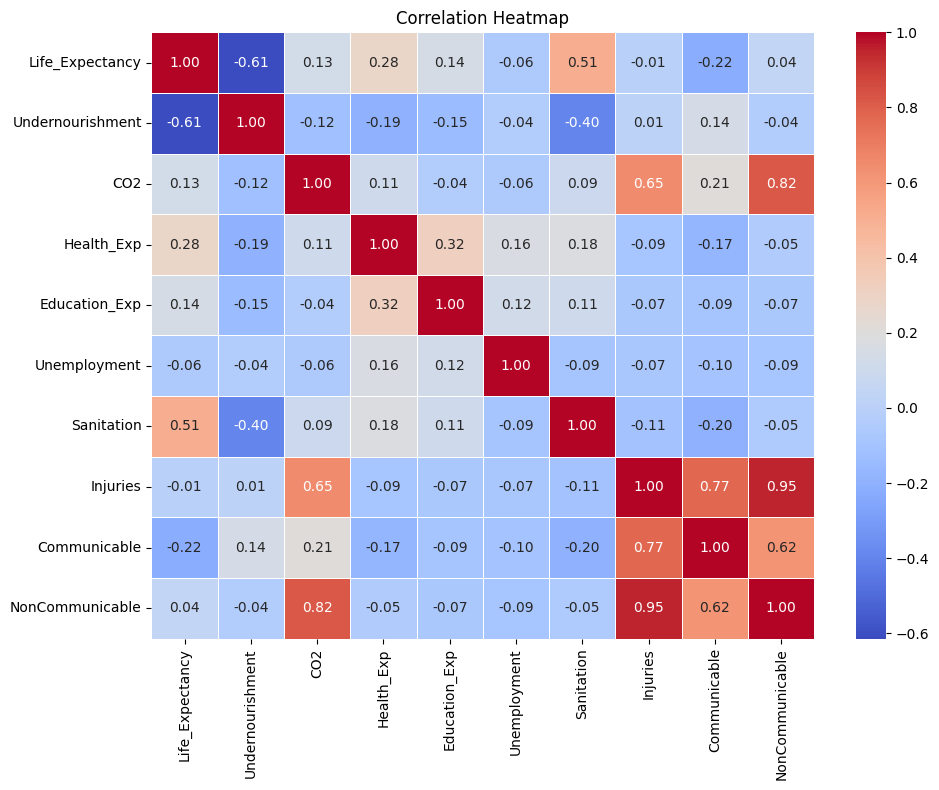

In [80]:
# Hitmap of the correlation on the cleaned dataset
plt.figure(figsize=(10, 8))
sns.heatmap(cleaned_data.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

Encode Categorical Variables

In [81]:
#Encoding the 'Income_Group' column using one-hot encoding
cleaned_data = pd.get_dummies(cleaned_data, 
                              columns=['Income_Group'], 
                              dtype=int, 
                              drop_first=True)

cleaned_data.head()

,Life_Expectancy,Undernourishment,CO2,Health_Exp,Education_Exp,Unemployment,Sanitation,Injuries,Communicable,NonCommunicable,Income_Group_Low income,Income_Group_Lower middle income,Income_Group_Upper middle income
0,56.308000,47.800000,730.0,6.364059,4.589014,10.809000,52.738785,2179727.10,9689193.70,5795426.38,1,0,0
1,47.059000,67.500000,15960.0,4.483516,4.589014,4.004000,52.738785,1392080.71,11190210.53,2663516.34,0,1,0
2,74.288000,4.900000,3230.0,7.139524,3.458700,18.575001,40.520895,117081.67,140894.78,532324.75,0,0,1
3,69.748362,10.663654,520.0,5.865939,4.589014,7.890760,21.788660,1697.99,695.56,13636.64,0,0,0
4,74.544000,2.800000,97200.0,2.484370,4.589014,2.493000,52.738785,144678.14,65271.91,481740.70,0,0,0


### Define Features, Target. Split Data & Scale Features

Looking at Life_Expectancy Heatmap Correlation, (Undernourshment, Sanitation, Health_Exp, Communicable, Education_Exp and CO2) show best correlation. 

In [100]:
# Identifying the features and target variable

# remain with every column except the target variable
X = cleaned_data.drop(columns=[
    'Life_Expectancy', 
    'Unemployment', 
    'Injuries', 
    'NonCommunicable',
    'CO2', # was giving 'misleading' positive coeefficient with life expectancy
    'Education_Exp' # was giving 'illogical negative coefficient' 
                    # maybe due to 30%+ missing values 
    ]) # features

y = cleaned_data[['Life_Expectancy']] # target variable

print('Features: ', X.columns.to_list())
print('Target: ', y.columns.to_list())
print('Shape of features: ', X.shape)
print('Shape of target: ', y.shape)

Features:  ['Undernourishment', 'Health_Exp', 'Sanitation', 'Communicable', 'Income_Group_Low income', 'Income_Group_Lower middle income', 'Income_Group_Upper middle income']
Target:  ['Life_Expectancy']
Shape of features:  (3306, 7)
Shape of target:  (3306, 1)


In [101]:
# Split the data into 80% training and 20% testing sets
# random_state=42 ensures reproducibility of the split
X_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print('Training set shape: ', X_train.shape, y_train.shape)
print('Testing set shape: ', x_test.shape, y_test.shape)


Training set shape:  (2644, 7) (2644, 1)
Testing set shape:  (662, 7) (662, 1)


Standardizing the data

In [102]:
# Standardize the features using StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(x_test)

#display the scaled training features
X_train_scaled[:5]


array([[ 4.02137925e+00, -9.57312614e-01, -3.27350639e-03,
        -8.52701624e-02, -3.90604566e-01,  1.69948089e+00,
        -6.30446669e-01],
       [-4.95269036e-01,  2.85953097e-02, -3.27350639e-03,
        -2.53534454e-01, -3.90604566e-01, -5.88414972e-01,
         1.58617699e+00],
       [-2.14233143e-01, -1.09876797e+00, -3.27350639e-03,
        -2.16822866e-01, -3.90604566e-01,  1.69948089e+00,
        -6.30446669e-01],
       [-6.05675994e-01, -2.97339039e-01, -2.13743942e-01,
        -2.53212900e-01, -3.90604566e-01,  1.69948089e+00,
        -6.30446669e-01],
       [ 2.93269682e-03, -8.24525523e-01, -1.20351586e+00,
        -2.41940728e-01, -3.90604566e-01, -5.88414972e-01,
         1.58617699e+00]])

In [103]:
#display the scaled testing features
x_test_scaled[:5]

array([[-0.66589797, -1.25391513, -0.00327351, -0.25028855, -0.39060457,
        -0.58841497,  1.58617699],
       [-0.61571299,  1.50295814, -0.00327351, -0.22732378, -0.39060457,
        -0.58841497,  1.58617699],
       [-0.65586098, -0.26580763, -1.13444278,  0.02014235, -0.39060457,
        -0.58841497,  1.58617699],
       [ 0.75935549, -0.65623846, -0.00327351,  0.40488935, -0.39060457,
         1.69948089, -0.63044667],
       [-0.81645291,  0.88460179,  1.04250457, -0.23253967, -0.39060457,
        -0.58841497, -0.63044667]])

## Training The Model

In [104]:
#Initializing and training the Linear Regression model
model = LinearRegression()

# fit the model on the training data 
model.fit(X_train_scaled, y_train)

print('Model initiated successfully!')

Model initiated successfully!


### Make Predictions

In [105]:
#predict life expectancy on the testing set  
y_pred = model.predict(x_test_scaled)

# compare the predicted values with the actual values
comparison = pd.DataFrame({
    'Actual data': y_test.values.flatten(),
    'Predicted data': y_pred.flatten().round(2),
    'Difference': (y_test.values.flatten() - y_pred.flatten()).round(2)})

print(comparison.head(15).to_string(index=False))

 Actual data  Predicted data  Difference
   65.863000           71.36       -5.50
   64.693000           73.35       -8.66
   75.296000           71.59        3.70
   51.682000           64.55      -12.87
   79.490244           78.70        0.79
   73.624390           72.90        0.73
   54.756000           59.29       -4.53
   75.128000           71.70        3.43
   55.508000           66.26      -10.75
   59.670000           56.90        2.77
   75.440000           75.39        0.05
   49.421000           58.78       -9.36
   75.054000           71.60        3.46
   77.688000           73.08        4.61
   72.248780           77.93       -5.68


Inspect model coefficient

In [108]:
#baseline life expectancy when all features = 0
print(f'Intercept: {model.intercept_[0]:.2f}')

#Dataframe of the coefficients of the features
coefficients_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_.flatten()
}).sort_values(by='Coefficient', key=abs, ascending=False)

print('\nFeature Coefficients (sorted by absolute value):')
print(coefficients_df.to_string(index=False))

Intercept: 69.95

Feature Coefficients (sorted by absolute value):
                         Feature  Coefficient
         Income_Group_Low income    -5.488940
Income_Group_Lower middle income    -3.958120
Income_Group_Upper middle income    -2.262496
                Undernourishment    -2.107797
                      Health_Exp     0.761978
                      Sanitation     0.361606
                    Communicable    -0.342367
